# 第一步：数据审计、防泄漏与时间切分

本 notebook 把原始议会投票数据整理成可用于英国政策利益相关者 Agent 的建模数据。本阶段不训练模型。

目标：

1. 检查字段、数据类型和每行数据的粒度；
2. 检查缺失值、重复值、议会、政党和时间覆盖；
3. 清洗文本，同时保持原始文件不变；
4. 区分投票前可用特征与投票后泄漏字段；
5. 构造可复现的政党立场标签；
6. 按当前项目范围保留英国下议院数据；
7. 按时间创建训练集、验证集和测试集。

> 注意：party_for、party_against、total_result 等字段只能在投票结束后获得。它们可以用于构造标签和审计，但不能作为模型输入。

## 1. 导入依赖并设置参数

如果之后需要调整项目范围或时间切分，只修改本单元格中的参数。

In [31]:
from pathlib import Path
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)
import hashlib
import html
import json
import re

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

DATA_CANDIDATES = [Path('all.csv'), Path('reorganised/all.csv')]
DATA_PATH = next((path.resolve() for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('找不到 all.csv。请从项目根目录或 reorganised 目录运行本 notebook。')

OUTPUT_DIR = DATA_PATH.parent / 'processed'
TARGET_CHAMBER = 'commons'
TARGET_PARTIES = ['conservative', 'green', 'labour', 'liberal-democrat']
TRAIN_END = pd.Timestamp('2023-12-31')
VALID_END = pd.Timestamp('2024-12-31')
WRITE_OUTPUTS = True

print(f'数据源：{DATA_PATH}')
print(f'输出目录：{OUTPUT_DIR}')

数据源：/Users/oooo1/01Course/2_70202Applying/reorganised/all.csv
输出目录：/Users/oooo1/01Course/2_70202Applying/reorganised/processed


## 2. 读取数据并记录来源指纹

SHA-256 指纹用于确认不同运行使用的是同一份源数据。后续处理只操作副本。

In [32]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as file:
        for chunk in iter(lambda: file.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

source_sha256 = sha256_file(DATA_PATH)
raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f'行数：{len(raw):,}')
print(f'列数：{raw.shape[1]}')
print(f'SHA-256：{source_sha256}')
display(raw.head(3))

行数：18,739
列数：27
SHA-256：3b782f0d73cbecc0457e285b7192b29c9cee540f66423060ec56308e9f7c3a46


,division_key,division_name,chamber_slug,motion_date,motion_title,motion_text,motion_type,legislation_id,legislation_name,legislation_slug,total_possible_members,total_for,total_against,total_absent,total_majority,total_for_percentage,total_result,grouping,party_vote_participant_count,party_total_possible_members,party_for,party_against,neutral_motion,party_absent,party_majority,party_for_percentage,party_result
0,pw-2016-01-06-157-commons,Opposition Day &#8212; Universal Credit Work Allowance &#8212; Decision to Cut,commons,2016/1/6,Opposition Day_ [14th Allotted Day]_ Universal Credit Work Allowance,"I beg to move,\nThat this House calls on the Government to reverse its decision to cut the universal credit work all...",other,NaN,NaN,NaN,650,273.0,308.0,65.0,-35.0,0.46988,-1,liberal-democrat,8,650,7.0,0.0,0.0,1.0,7.0,1.0,1
1,pw-2016-01-06-157-commons,Opposition Day &#8212; Universal Credit Work Allowance &#8212; Decision to Cut,commons,2016/1/6,Opposition Day_ [14th Allotted Day]_ Universal Credit Work Allowance,"I beg to move,\nThat this House calls on the Government to reverse its decision to cut the universal credit work all...",other,NaN,NaN,NaN,650,273.0,308.0,65.0,-35.0,0.46988,-1,labour,232,650,204.0,0.0,0.0,26.0,204.0,1.0,1
2,pw-2016-01-06-157-commons,Opposition Day &#8212; Universal Credit Work Allowance &#8212; Decision to Cut,commons,2016/1/6,Opposition Day_ [14th Allotted Day]_ Universal Credit Work Allowance,"I beg to move,\nThat this House calls on the Government to reverse its decision to cut the universal credit work all...",other,NaN,NaN,NaN,650,273.0,308.0,65.0,-35.0,0.46988,-1,conservative,330,650,0.0,308.0,0.0,20.0,-308.0,0.0,-1


## 3. 检查字段结构

如果之后重新抓取的数据缺少必要字段，本单元格会立即报错。新增字段只会被列出，不会中断运行。

In [33]:
EXPECTED_COLUMNS = [
    'division_key', 'division_name', 'chamber_slug', 'motion_date',
    'motion_title', 'motion_text', 'motion_type', 'legislation_id',
    'legislation_name', 'legislation_slug', 'total_possible_members',
    'total_for', 'total_against', 'total_absent', 'total_majority',
    'total_for_percentage', 'total_result', 'grouping',
    'party_vote_participant_count', 'party_total_possible_members',
    'party_for', 'party_against', 'neutral_motion', 'party_absent',
    'party_majority', 'party_for_percentage', 'party_result'
]

missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw.columns))
extra_columns = sorted(set(raw.columns) - set(EXPECTED_COLUMNS))
if missing_columns:
    raise ValueError(f'缺少必要字段：{missing_columns}')

schema = pd.DataFrame({
    '字段': raw.columns,
    '数据类型': raw.dtypes.astype(str).values,
    '非空数量': raw.notna().sum().values,
    '缺失数量': raw.isna().sum().values,
    '缺失比例_pct': (raw.isna().mean().values * 100).round(2),
    '唯一值数量': raw.nunique(dropna=True).values,
})

print('新增字段：', extra_columns if extra_columns else '无')
display(schema)

新增字段： 无


,字段,数据类型,非空数量,缺失数量,缺失比例_pct,唯一值数量
0,division_key,object,18739,0,0.00,4372
1,division_name,object,18739,0,0.00,2084
2,chamber_slug,object,18739,0,0.00,2
3,motion_date,object,18739,0,0.00,862
4,motion_title,object,18739,0,0.00,3611
5,motion_text,object,18739,0,0.00,3331
6,motion_type,object,18739,0,0.00,24
7,legislation_id,float64,5487,13252,70.72,86
8,legislation_name,object,5487,13252,70.72,86
9,legislation_slug,object,5487,13252,70.72,86


## 4. 解析日期并清洗文本

清洗包括解析 HTML 实体、统一空白字符，以及把 motion_title 中作为分隔符的下划线替换为破折号。原始文本仍保留在 raw 中。

In [34]:
def clean_text(value, replace_title_separator=False):
    if pd.isna(value):
        return pd.NA
    text = html.unescape(str(value)).replace('\xa0', ' ')
    if replace_title_separator:
        text = re.sub(r'\s*_\s*', ' — ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else pd.NA

df = raw.copy()
df['motion_date'] = pd.to_datetime(df['motion_date'], errors='coerce')
df['division_name_clean'] = df['division_name'].map(clean_text)
df['motion_title_clean'] = df['motion_title'].map(lambda x: clean_text(x, replace_title_separator=True))
df['motion_text_clean'] = df['motion_text'].map(clean_text)
df['legislation_name_clean'] = df['legislation_name'].map(clean_text)
df['motion_year'] = df['motion_date'].dt.year.astype('Int64')
df['motion_month'] = df['motion_date'].dt.month.astype('Int64')
df['motion_char_count'] = df['motion_text_clean'].str.len().astype('Int64')
df['motion_word_count'] = df['motion_text_clean'].str.split().str.len().astype('Int64')

print('无法解析的日期数量：', int(df['motion_date'].isna().sum()))
display(df[['division_name', 'division_name_clean', 'motion_title', 'motion_title_clean']].head(3))

无法解析的日期数量： 0


,division_name,division_name_clean,motion_title,motion_title_clean
0,Opposition Day &#8212; Universal Credit Work Allowance &#8212; Decision to Cut,Opposition Day — Universal Credit Work Allowance — Decision to Cut,Opposition Day_ [14th Allotted Day]_ Universal Credit Work Allowance,Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance
1,Opposition Day &#8212; Universal Credit Work Allowance &#8212; Decision to Cut,Opposition Day — Universal Credit Work Allowance — Decision to Cut,Opposition Day_ [14th Allotted Day]_ Universal Credit Work Allowance,Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance
2,Opposition Day &#8212; Universal Credit Work Allowance &#8212; Decision to Cut,Opposition Day — Universal Credit Work Allowance — Decision to Cut,Opposition Day_ [14th Allotted Day]_ Universal Credit Work Allowance,Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance


## 5. 检查数据粒度、重复值与主键

预期每行代表一个 division_key 与 grouping 的组合。同一议案对应多个政党，因此不能随机切分行。

In [35]:
exact_duplicate_rows = int(df.duplicated().sum())
duplicate_division_party = int(df.duplicated(['division_key', 'grouping']).sum())
null_key_rows = int(df[['division_key', 'grouping']].isna().any(axis=1).sum())

key_audit = pd.Series({
    '总行数': len(df),
    '唯一议案数量': df['division_key'].nunique(),
    '唯一议案政党组合数量': df[['division_key', 'grouping']].drop_duplicates().shape[0],
    '完全重复行数量': exact_duplicate_rows,
    '重复议案政党组合数量': duplicate_division_party,
    '主键为空的行数': null_key_rows,
}, name='数值')
display(key_audit.to_frame())

assert null_key_rows == 0, '主键字段存在空值。'
assert duplicate_division_party == 0, '存在重复的议案政党组合，建模前需要调查。'

,数值
总行数,18739
唯一议案数量,4372
唯一议案政党组合数量,18739
完全重复行数量,0
重复议案政党组合数量,0
主键为空的行数,0


## 6. 检查缺失值与分类字段覆盖

In [36]:
missingness = pd.DataFrame({
    '缺失数量': df.isna().sum(),
    '缺失比例_pct': (df.isna().mean() * 100).round(2),
}).sort_values(['缺失比例_pct', '缺失数量'], ascending=False)
display(missingness.head(20))

for column in ['chamber_slug', 'grouping', 'motion_type', 'party_result']:
    print(f'\n字段：{column}')
    display(df[column].value_counts(dropna=False).sort_index().to_frame('行数'))

,缺失数量,缺失比例_pct
legislation_id,13252,70.72
legislation_name,13252,70.72
legislation_slug,13252,70.72
legislation_name_clean,13252,70.72
party_for_percentage,1580,8.43
division_key,0,0.00
division_name,0,0.00
chamber_slug,0,0.00
motion_date,0,0.00
motion_title,0,0.00



字段：chamber_slug


,行数
chamber_slug,
commons,8948
scotland,9791



字段：grouping


,行数
grouping,
conservative,4372
green,4372
labour,4372
liberal-democrat,4372
reform,1251



字段：motion_type


,行数
motion_type,
add_clause_to_bill,370
adjournment,24
amendment,9667
approve_statutory_instrument,901
bill_introduction,90
closure,26
committee_clause,103
eu_document_scrutiny,32
financial,10



字段：party_result


,行数
party_result,
-1,8207
0,1596
1,8936


## 7. 检查投票字段的一致性

检查多数票、结果和百分比字段是否能由基础票数复算。议员人数不强制完全相等，因为计票员、空缺席位、议长和数据源定义可能造成小幅差异。

In [37]:
expected_total_result = np.sign(df['total_for'] - df['total_against'])
expected_party_result = np.sign(df['party_for'] - df['party_against'])
total_denominator = df['total_for'] + df['total_against']
party_denominator = df['party_for'] + df['party_against']
expected_total_pct = df['total_for'].div(total_denominator.where(total_denominator.ne(0)))
expected_party_pct = df['party_for'].div(party_denominator.where(party_denominator.ne(0)))

df['total_membership_residual'] = (
    df['total_possible_members'] - df['total_for'].fillna(0)
    - df['total_against'].fillna(0) - df['total_absent'].fillna(0)
)
df['party_membership_residual'] = (
    df['party_vote_participant_count'] - df['party_for'].fillna(0)
    - df['party_against'].fillna(0) - df['neutral_motion'].fillna(0)
    - df['party_absent'].fillna(0)
)

consistency_checks = pd.Series({
    'total_majority不一致行数': int((df['total_majority'] != df['total_for'] - df['total_against']).sum()),
    'party_majority不一致行数': int((df['party_majority'] != df['party_for'] - df['party_against']).sum()),
    'total_result不一致行数': int((expected_total_result != df['total_result']).sum()),
    'party_result不一致行数': int((expected_party_result != df['party_result']).sum()),
    'total_for_percentage不一致行数': int((expected_total_pct - df['total_for_percentage']).abs().fillna(0).gt(1e-9).sum()),
    'party_for_percentage不一致行数': int((expected_party_pct - df['party_for_percentage']).abs().fillna(0).gt(1e-9).sum()),
    'party_total_possible_members与总人数相同行数': int((df['party_total_possible_members'] == df['total_possible_members']).sum()),
}, name='检查结果')
display(consistency_checks.to_frame())
print('议会总人数残差分布')
display(df['total_membership_residual'].describe().to_frame().T)
print('政党人数残差分布')
display(df['party_membership_residual'].describe().to_frame().T)

,检查结果
total_majority不一致行数,0
party_majority不一致行数,0
total_result不一致行数,0
party_result不一致行数,0
total_for_percentage不一致行数,0
party_for_percentage不一致行数,0
party_total_possible_members与总人数相同行数,18739


议会总人数残差分布


,count,mean,std,min,25%,50%,75%,max
total_membership_residual,18739.0,2.949517,5.381528,-17.0,0.0,3.0,4.0,75.0


政党人数残差分布


,count,mean,std,min,25%,50%,75%,max
party_membership_residual,18739.0,0.381344,0.814039,0.0,0.0,0.0,0.0,4.0


## 8. 检查议会、政党与年份覆盖

原始数据同时包含英国下议院和苏格兰议会投票。当前项目范围是英国下议院，因此第一版模型只保留 commons。

grouping,conservative,green,labour,liberal-democrat,reform
chamber_slug,,,,,
commons,2091,2091,2091,2091,584
scotland,2281,2281,2281,2281,667


chamber_slug,commons,scotland
motion_year,,
2016,556,0
2017,328,0
2018,452,0
2019,724,0
2020,756,0
2021,968,1120
2022,1004,1752
2023,1024,1496
2024,946,1536


/var/folders/tk/r_n7kv150lj5lky4nj__dc7r0000gn/T/ipykernel_33958/3057232265.py:11: UserWarning: Glyph 35758 (\N{CJK UNIFIED IDEOGRAPH-8BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tk/r_n7kv150lj5lky4nj__dc7r0000gn/T/ipykernel_33958/3057232265.py:11: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tk/r_n7kv150lj5lky4nj__dc7r0000gn/T/ipykernel_33958/3057232265.py:11: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tk/r_n7kv150lj5lky4nj__dc7r0000gn/T/ipykernel_33958/3057232265.py:11: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tk/r_n7kv150lj5lky4nj__dc7r0000gn/T/ipykernel_33958/3057232265.py:11: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tk/r_n7

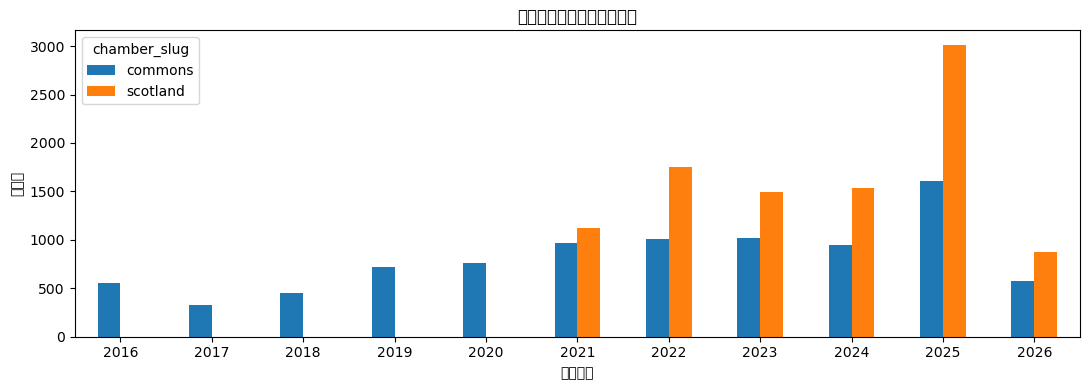

In [38]:
chamber_party = pd.crosstab(df['chamber_slug'], df['grouping'])
year_chamber = pd.crosstab(df['motion_year'], df['chamber_slug'])
display(chamber_party)
display(year_chamber)

if plt is not None:
    year_chamber.plot(kind='bar', figsize=(11, 4), title='按年份和议会统计的记录数')
    plt.ylabel('记录数')
    plt.xlabel('议案年份')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('当前环境未安装 matplotlib，已跳过图表；其余 EDA 不受影响。')

## 9. 应用第一版产品范围

本阶段保留下议院的 Conservative、Green、Labour 和 Liberal Democrat 四个政党。Reform 不在本项目的研究范围内。暂不删除程序性投票，因为该规则需要单独定义并记录。

In [39]:
scoped = (
    df.loc[df['chamber_slug'].eq(TARGET_CHAMBER) & df['grouping'].isin(TARGET_PARTIES)]
    .copy()
    .sort_values(['motion_date', 'division_key', 'grouping'])
    .reset_index(drop=True)
)
scoped['party'] = scoped['grouping']
scoped['row_id'] = scoped['division_key'].astype(str) + '__' + scoped['party'].astype(str)

scope_summary = pd.Series({
    '行数': len(scoped),
    '唯一议案数量': scoped['division_key'].nunique(),
    '最早日期': scoped['motion_date'].min(),
    '最晚日期': scoped['motion_date'].max(),
    '政党数量': scoped['party'].nunique(),
}, name='数值')
display(scope_summary.to_frame())
display(pd.crosstab(scoped['motion_year'], scoped['party']))

assert scoped['row_id'].is_unique, '范围筛选后的 row_id 必须唯一。'
assert scoped['motion_date'].notna().all(), '筛选后的数据仍存在无效日期。'

,数值
行数,8364
唯一议案数量,2091
最早日期,2016-01-06 00:00:00
最晚日期,2026-04-27 00:00:00
政党数量,4


party,conservative,green,labour,liberal-democrat
motion_year,,,,
2016,139,139,139,139
2017,82,82,82,82
2018,113,113,113,113
2019,181,181,181,181
2020,189,189,189,189
2021,242,242,242,242
2022,251,251,251,251
2023,256,256,256,256
2024,200,200,200,200


## 10. 归一化表决极性并构造预测标签

party_result 只表示该党投 Aye、没有多数方向或投 No，不能直接解释为支持或反对政策对象。一个 Aye 可能表示通过法案，也可能表示删除条款、撤回政策或否决修正案。

本步骤先根据 motion title、motion text 和 motion type 判断 Aye 相对基础政策对象的方向：1 表示 Aye 支持对象，-1 表示 Aye 否定对象，缺失表示规则无法可靠判断，需要人工复核。正式政策立场等于原始投票方向乘以 motion_polarity。

五档暂定标签根据归一化后的 policy stance score 划分：小于 -0.60 为 strongly oppose，-0.60 至小于 -0.20 为 oppose，-0.20 至小于 0.20 为 mixed or neutral，0.20 至小于 0.60 为 support，大于等于 0.60 为 strongly support。该标签用于探索，不作为第一版主模型目标。

In [40]:
consensus_denominator = scoped[['party_for', 'party_against', 'neutral_motion']].fillna(0).sum(axis=1)
scoped['raw_vote_direction'] = scoped['party_result'].map({-1: 'no', 0: 'neutral_or_tied', 1: 'aye'})
scoped['raw_vote_score'] = (
    (scoped['party_for'] - scoped['party_against'])
    .div(consensus_denominator.where(consensus_denominator.ne(0)))
)

NEGATIVE_POLARITY_RULES = [
    ('decline_reading', r'\bdeclines? to give\b.{0,160}\b(?:second|third) reading\b'),
    ('not_read', r'\bnot be (?:now )?read\b'),
    ('leave_out', r'\bleave out\b'),
    ('not_stand_part', r'\b(?:clause|schedule|section|subsection)\b.{0,160}\bnot stand part\b'),
    ('disagree_lords', r'\bdisagrees? with (?:the )?lords?\b'),
    ('insist_disagreement', r'\binsists? on.{0,200}\bdisagreement\b'),
    ('reverse_or_remove', r'\b(?:revoke|annul|withdraw|reverse|repeal|abandon|reject|delete)\b'),
    ('do_not_approve', r'\bdo not approve\b'),
]
POSITIVE_POLARITY_RULES = [
    ('approve', r'\bbe approved\b'),
    ('reading', r'\bbe (?:now )?read (?:a |the )?(?:second|third) time\b'),
    ('stand_part', r'\b(?:clause|schedule)\b.{0,160}\bstand part\b'),
    ('agree_lords', r'\bagrees? with (?:the )?lords?\b'),
    ('insert_or_add', r'\b(?:insert|add)\b'),
]
POSITIVE_TYPE_DEFAULTS = {
    'approve_statutory_instrument', 'second_stage', 'third_stage',
    'bill_introduction', 'committee_clause', 'add_clause_to_bill', 'proposed_clause',
}
NEGATIVE_TYPE_DEFAULTS = {'revoke_statutory_instrument', 'reasoned_amendment'}
MULTI_OBJECT_PATTERNS = [
    r'\binsists? on.{0,220}\band disagrees? with\b',
    r'\bdisagrees? with.{0,260}\b(?:proposes?|agrees?).{0,160}\bin lieu\b',
    r'\bamendment.{0,120}\bin lieu of (?:a |the )?lords? amendment',
    r'\bleave out\b.{0,300}\b(?:and )?(?:insert|add)(?:\b|_)',
    r'\binsists? on (?:its )?disagreement\b.{0,220}\bproposes?.{0,120}\bin lieu\b',
    r'\bresolution.{0,180}\bbe rescinded\b.{0,120}\borders? be made\b',
]

def classify_motion_polarity(row):
    text = ' '.join([
        str(row.get('division_name_clean') or ''),
        str(row.get('motion_title_clean') or ''),
        str(row.get('motion_text_clean') or ''),
    ]).lower()
    # 当前实际Question优先于后文附带展示的修正案文字。
    if re.search(r'\boriginal words stand part of the question\b', text):
        return 1, 'original_words_stand', 'high'
    if re.search(r'\bproposed words be there added\b', text):
        return 1, 'proposed_words_added', 'high'
    # 同一动议同时支持一个对象、反对另一个对象时，不能在未定义policy_object前压成单一方向。
    if any(re.search(pattern, text) for pattern in MULTI_OBJECT_PATTERNS):
        return pd.NA, 'multi_object_manual_review', 'unknown'
    # 否定withdraw/revoke等动作表示阻止删除或退出，方向与关键词本身相反。
    if re.search(
        r'\b(?:no .{0,100}|not .{0,100}|may not .{0,100}|must not .{0,100})'
        r'(?:withdrawal|withdraw|revoke|repeal|remove)\b',
        text,
    ):
        return 1, 'prevent_reverse_or_remove', 'high'
    for rule_name, pattern in NEGATIVE_POLARITY_RULES:
        if re.search(pattern, text):
            return -1, rule_name, 'high'
    for rule_name, pattern in POSITIVE_POLARITY_RULES:
        if re.search(pattern, text):
            return 1, rule_name, 'high'
    if row['motion_type'] in NEGATIVE_TYPE_DEFAULTS:
        return -1, f'type:{row["motion_type"]}', 'medium'
    if row['motion_type'] in POSITIVE_TYPE_DEFAULTS:
        return 1, f'type:{row["motion_type"]}', 'medium'
    return pd.NA, 'manual_review', 'unknown'

polarity_values = scoped.apply(classify_motion_polarity, axis=1, result_type='expand')
polarity_values.columns = ['motion_polarity', 'polarity_rule', 'polarity_confidence']
scoped = pd.concat([scoped, polarity_values], axis=1)
scoped['motion_polarity'] = scoped['motion_polarity'].astype('Int64')

government_change_date = pd.Timestamp('2024-07-05')
scoped['government_party'] = np.where(
    scoped['motion_date'].lt(government_change_date), 'conservative', 'labour'
)
scoped['main_opposition_party'] = np.where(
    scoped['motion_date'].lt(government_change_date), 'labour', 'conservative'
)
scoped['party_role'] = np.select(
    [
        scoped['party'].eq(scoped['government_party']),
        scoped['party'].eq(scoped['main_opposition_party']),
    ],
    ['governing_party', 'main_opposition'],
    default='smaller_opposition',
)

def classify_government_backing(row):
    text = ' '.join([
        str(row.get('division_name_clean') or ''),
        str(row.get('motion_title_clean') or ''),
        str(row.get('motion_text_clean') or ''),
    ]).lower()
    if 'opposition day' in text:
        return 0, 'opposition_day', 'high'
    if re.search(r'\bgovernment (?:motion|amendment)\b', text):
        return 1, 'explicit_government_motion', 'high'
    if row['motion_type'] in {'government_agenda', 'approve_statutory_instrument', 'programme', 'financial'}:
        return 1, f'type:{row["motion_type"]}', 'medium'
    if row['motion_type'] == 'reasoned_amendment':
        return 0, 'type:reasoned_amendment', 'medium'
    return pd.NA, 'manual_review', 'unknown'

backing_values = scoped.apply(classify_government_backing, axis=1, result_type='expand')
backing_values.columns = [
    'object_government_backed', 'government_backing_rule', 'government_backing_confidence'
]
scoped = pd.concat([scoped, backing_values], axis=1)
scoped['object_government_backed'] = scoped['object_government_backed'].astype('Int64')

scoped['target_policy_stance_score'] = (
    scoped['raw_vote_score'].astype('Float64') * scoped['motion_polarity'].astype('Float64')
)
scoped['target_policy_result'] = scoped['target_policy_stance_score'].map(
    lambda value: pd.NA if pd.isna(value) else int(np.sign(value))
).astype('Int64')
scoped['target_policy_stance'] = scoped['target_policy_result'].map({
    -1: 'oppose', 0: 'mixed_or_neutral', 1: 'support'
})
scoped['target_binary_support'] = scoped['target_policy_result'].map({-1: 0, 1: 1}).astype('Int64')

ordinal_labels = ['strongly_oppose', 'oppose', 'mixed_or_neutral', 'support', 'strongly_support']
scoped['target_ordinal_provisional'] = pd.cut(
    scoped['target_policy_stance_score'].astype(float),
    bins=[-np.inf, -0.60, -0.20, 0.20, 0.60, np.inf],
    labels=ordinal_labels,
    include_lowest=True,
    right=False,
).astype('string')

print('原始 Aye/No 方向分布')
display(scoped['raw_vote_direction'].value_counts(dropna=False).to_frame('行数'))
print('Motion polarity 规则覆盖')
display(scoped.groupby(['polarity_confidence', 'motion_polarity'], dropna=False).size().to_frame('行数'))
print('归一化后的政策立场分布')
display(scoped['target_policy_stance'].value_counts(dropna=False).to_frame('行数'))
print('暂定五档政策立场分布')
display(scoped['target_ordinal_provisional'].value_counts(dropna=False).to_frame('行数'))
print('各政党的归一化政策立场占比')
display(scoped.groupby('party')['target_policy_result'].value_counts(normalize=True).rename('占比').unstack(fill_value=0).round(3))

known_backing = scoped['object_government_backed'].notna() & scoped['target_policy_stance'].notna()
print('政府背书与政党角色的信号检查，仅使用规则可判断的议案')
display(pd.crosstab(
    [
        scoped.loc[known_backing, 'object_government_backed'].map({0: 'not_government_backed', 1: 'government_backed'}),
        scoped.loc[known_backing, 'party_role'],
    ],
    scoped.loc[known_backing, 'target_policy_stance'],
    normalize='index',
).round(3))

原始 Aye/No 方向分布


,行数
raw_vote_direction,
aye,3935
no,3612
neutral_or_tied,817


Motion polarity 规则覆盖


行数
polarity_confidence motion_polarity      
high                -1               2028
                    1                2576
medium              -1                 16
                    1                 908
unknown             <NA>             2836

归一化后的政策立场分布


...

,行数
target_ordinal_provisional,
<NA>,3326
strongly_support,2941
strongly_oppose,2046
mixed_or_neutral,21
support,19
oppose,11


各政党的归一化政策立场占比


target_policy_result,-1,0,1
party,,,
conservative,0.52,0.002,0.477
green,0.362,0.0,0.638
labour,0.432,0.001,0.567
liberal-democrat,0.31,0.003,0.687


政府背书与政党角色的信号检查，仅使用规则可判断的议案


target_policy_stance                         mixed_or_neutral  oppose  support
object_government_backed party_role                                           
government_backed        governing_party                0.000   0.113    0.887
                         main_opposition                0.005   0.741    0.255
                         smaller_opposition             0.003   0.639    0.359
not_government_backed    governing_party                0.000   0.566    0.434
                         main_opposition                0.000   0.351    0.649
                         smaller_opposition             0.000   0.433    0.567

## 11. 建立特征与泄漏字段登记表

只有角色为 feature 的字段可以进入第一版模型。投票后字段保留在审计数据中，但不会进入 model-ready 数据。

In [41]:
POST_VOTE_LEAKAGE = [
    'total_for', 'total_against', 'total_absent', 'total_majority',
    'total_for_percentage', 'total_result', 'party_for', 'party_against',
    'neutral_motion', 'party_absent', 'party_majority', 'party_for_percentage',
    'party_result', 'raw_vote_direction', 'raw_vote_score',
]
TARGET_COLUMNS = [
    'target_policy_result', 'target_policy_stance', 'target_binary_support',
    'target_policy_stance_score', 'target_ordinal_provisional',
]
BASELINE_FEATURES = [
    'motion_date', 'party', 'motion_title_clean', 'motion_text_clean',
    'motion_type', 'legislation_name_clean', 'total_possible_members',
    'motion_year', 'motion_month', 'motion_char_count', 'motion_word_count',
    'party_role', 'motion_polarity',
]
IDENTIFIERS = ['row_id', 'division_key']
NORMALIZATION_METADATA = [
    'polarity_rule', 'polarity_confidence', 'government_party',
    'main_opposition_party', 'government_backing_rule', 'government_backing_confidence',
    'object_government_backed',
]
REVIEW_EXCLUDED = ['party_vote_participant_count', 'party_total_possible_members']

registry_rows = []
for column in scoped.columns:
    if column in POST_VOTE_LEAKAGE:
        role, allowed, note = 'post_vote_leakage', False, '当前投票结束后才可获得，只能用于审计或构造标签。'
    elif column in TARGET_COLUMNS:
        role, allowed, note = 'target', False, '预测目标，或由历史投票数构造的目标。'
    elif column in BASELINE_FEATURES:
        role, allowed, note = 'feature', True, '第一版产品流程中可在投票前获得。'
    elif column in IDENTIFIERS:
        role, allowed, note = 'identifier', False, '用于关联、分组、追踪和防泄漏切分。'
    elif column in NORMALIZATION_METADATA:
        role, allowed, note = 'normalization_metadata', False, '记录极性或政府背书规则的来源与置信度，不直接进入模型。'
    elif column in REVIEW_EXCLUDED:
        role, allowed, note = 'review_excluded', False, '定义含糊或与其他字段重复，第一版排除。'
    else:
        role, allowed, note = 'context_excluded', False, '保留在审计数据中，第一版模型不使用。'
    registry_rows.append({'字段': column, '角色': role, '推理时可用': allowed, '说明': note})

feature_registry = pd.DataFrame(registry_rows).sort_values(['角色', '字段']).reset_index(drop=True)
display(feature_registry)

,字段,角色,推理时可用,说明
0,chamber_slug,context_excluded,False,保留在审计数据中，第一版模型不使用。
1,division_name,context_excluded,False,保留在审计数据中，第一版模型不使用。
2,division_name_clean,context_excluded,False,保留在审计数据中，第一版模型不使用。
3,grouping,context_excluded,False,保留在审计数据中，第一版模型不使用。
4,legislation_id,context_excluded,False,保留在审计数据中，第一版模型不使用。
5,legislation_name,context_excluded,False,保留在审计数据中，第一版模型不使用。
6,legislation_slug,context_excluded,False,保留在审计数据中，第一版模型不使用。
7,motion_text,context_excluded,False,保留在审计数据中，第一版模型不使用。
8,motion_title,context_excluded,False,保留在审计数据中，第一版模型不使用。
9,party_membership_residual,context_excluded,False,保留在审计数据中，第一版模型不使用。


## 12. 进行防泄漏时间切分

训练集使用 2023 年及以前的数据，验证集使用 2024 年，测试集使用 2025 年及以后数据。每个 division_key 只能进入一个数据集。

In [42]:
scoped['split'] = np.select(
    [scoped['motion_date'].le(TRAIN_END), scoped['motion_date'].le(VALID_END)],
    ['train', 'validation'],
    default='test',
)

split_summary = scoped.groupby('split').agg(
    行数=('row_id', 'size'),
    议案数量=('division_key', 'nunique'),
    最早日期=('motion_date', 'min'),
    最晚日期=('motion_date', 'max'),
    政党数量=('party', 'nunique'),
    归一化二分类有效行数=('target_binary_support', 'count'),
    极性可判定行数=('motion_polarity', 'count'),
    政府背书可判定行数=('object_government_backed', 'count'),
).reindex(['train', 'validation', 'test'])
display(split_summary)
display(pd.crosstab(scoped['split'], scoped['party']))

division_sets = {name: set(group['division_key']) for name, group in scoped.groupby('split')}
split_overlap = {
    '训练集_验证集': len(division_sets['train'] & division_sets['validation']),
    '训练集_测试集': len(division_sets['train'] & division_sets['test']),
    '验证集_测试集': len(division_sets['validation'] & division_sets['test']),
}
print('不同数据集之间重复的议案数量：', split_overlap)
assert sum(split_overlap.values()) == 0, '同一个议案出现在多个数据集中。'

,行数,议案数量,最早日期,最晚日期,政党数量,归一化二分类有效行数,极性可判定行数,政府背书可判定行数
split,,,,,,,,
train,5812,1453,2016-01-06,2023-12-13,4,3403,3704,1140
validation,800,200,2024-01-09,2024-12-17,4,489,568,164
test,1752,438,2025-01-08,2026-04-27,4,1138,1256,368


party,conservative,green,labour,liberal-democrat
split,,,,
test,438,438,438,438
train,1453,1453,1453,1453
validation,200,200,200,200


不同数据集之间重复的议案数量： {'训练集_验证集': 0, '训练集_测试集': 0, '验证集_测试集': 0}


## 13. 生成 model-ready 数据

该数据只包含标识字段、获准使用的基线特征、极性归一化审计信息、预测目标和数据集标签，所有投票后泄漏字段均被排除。模型训练时只允许从 BASELINE_FEATURES 中选择输入。

In [43]:
MODEL_READY_COLUMNS = IDENTIFIERS + BASELINE_FEATURES + NORMALIZATION_METADATA + TARGET_COLUMNS + ['split']
model_ready = scoped[MODEL_READY_COLUMNS].copy()

unexpected_leakage = sorted(set(model_ready.columns) & set(POST_VOTE_LEAKAGE))
assert not unexpected_leakage, f'model-ready 数据中发现泄漏字段：{unexpected_leakage}'
assert model_ready['row_id'].is_unique, 'model-ready 数据的 row_id 不唯一。'

train = model_ready.loc[model_ready['split'].eq('train')].reset_index(drop=True)
validation = model_ready.loc[model_ready['split'].eq('validation')].reset_index(drop=True)
test = model_ready.loc[model_ready['split'].eq('test')].reset_index(drop=True)

print(f'model-ready 数据维度：{model_ready.shape}')
display(model_ready.head(3))

model-ready 数据维度：(8364, 28)


,row_id,division_key,motion_date,party,motion_title_clean,motion_text_clean,motion_type,legislation_name_clean,total_possible_members,motion_year,motion_month,motion_char_count,motion_word_count,party_role,motion_polarity,polarity_rule,polarity_confidence,government_party,main_opposition_party,government_backing_rule,government_backing_confidence,object_government_backed,target_policy_result,target_policy_stance,target_binary_support,target_policy_stance_score,target_ordinal_provisional,split
0,pw-2016-01-06-157-commons__conservative,pw-2016-01-06-157-commons,2016-01-06,conservative,Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance,"I beg to move, That this House calls on the Government to reverse its decision to cut the universal credit work allo...",other,<NA>,650,2016,1,170,32,governing_party,-1,reverse_or_remove,high,conservative,labour,opposition_day,high,0,1,support,1,1.0,strongly_support,train
1,pw-2016-01-06-157-commons__green,pw-2016-01-06-157-commons,2016-01-06,green,Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance,"I beg to move, That this House calls on the Government to reverse its decision to cut the universal credit work allo...",other,<NA>,650,2016,1,170,32,smaller_opposition,-1,reverse_or_remove,high,conservative,labour,opposition_day,high,0,-1,oppose,0,-1.0,strongly_oppose,train
2,pw-2016-01-06-157-commons__labour,pw-2016-01-06-157-commons,2016-01-06,labour,Opposition Day — [14th Allotted Day] — Universal Credit Work Allowance,"I beg to move, That this House calls on the Government to reverse its decision to cut the universal credit work allo...",other,<NA>,650,2016,1,170,32,main_opposition,-1,reverse_or_remove,high,conservative,labour,opposition_day,high,0,-1,oppose,0,-1.0,strongly_oppose,train


## 14. 导出可复现的数据文件

审计数据保留投票后字段，方便检查；model-ready 数据不包含这些字段。如只想查看分析而不写文件，可把 WRITE_OUTPUTS 改为 False。

In [44]:
quality_report = {
    '源文件': DATA_PATH.name,
    '源文件_sha256': source_sha256,
    '原始行数': int(len(raw)),
    '原始列数': int(raw.shape[1]),
    '原始唯一议案数量': int(raw['division_key'].nunique()),
    '完全重复行数': exact_duplicate_rows,
    '重复议案政党组合数量': duplicate_division_party,
    '目标议会': TARGET_CHAMBER,
    '目标政党': TARGET_PARTIES,
    '筛选后行数': int(len(scoped)),
    '筛选后唯一议案数量': int(scoped['division_key'].nunique()),
    '最早日期': scoped['motion_date'].min().date().isoformat(),
    '最晚日期': scoped['motion_date'].max().date().isoformat(),
    '各数据集行数': {name: int(count) for name, count in scoped['split'].value_counts().to_dict().items()},
    '数据集议案重叠': split_overlap,
    '极性可判定行数': int(scoped['motion_polarity'].notna().sum()),
    '极性规则覆盖率': round(float(scoped['motion_polarity'].notna().mean()), 4),
    '政府背书可判定行数': int(scoped['object_government_backed'].notna().sum()),
    '投票后泄漏字段': POST_VOTE_LEAKAGE,
    '第一版基线特征': BASELINE_FEATURES,
    '说明': [
        '第一版产品范围排除了苏格兰议会记录。',
        'Reform 已从研究范围中删除，训练、验证和测试均只包含四个目标政党。',
        'party_total_possible_members 与 total_possible_members 完全重复，因此排除。',
        'party_vote_participant_count 的源字段定义需要确认，因此第一版排除。',
        '正式目标使用经过 motion polarity 归一化后的政策立场，不再把 Aye 直接等同于支持。',
        '无法通过高或中置信度规则判断极性的议案保留为待人工复核，不进入有监督训练。',
        '五档标签基于归一化后的立场分数，仍为探索性标签。',
    ],
}

if WRITE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    scoped.to_csv(OUTPUT_DIR / 'commons_party_motion_audit.csv', index=False)
    model_ready.to_csv(OUTPUT_DIR / 'model_ready_all.csv', index=False)
    train.to_csv(OUTPUT_DIR / 'model_train.csv', index=False)
    validation.to_csv(OUTPUT_DIR / 'model_validation.csv', index=False)
    test.to_csv(OUTPUT_DIR / 'model_test.csv', index=False)
    feature_registry.to_csv(OUTPUT_DIR / 'feature_registry.csv', index=False)
    with (OUTPUT_DIR / 'data_quality_report.json').open('w', encoding='utf-8') as file:
        json.dump(quality_report, file, ensure_ascii=False, indent=2)

    print('已生成以下文件：')
    for path in sorted(OUTPUT_DIR.iterdir()):
        print(f'  {path.name}')
else:
    print('WRITE_OUTPUTS 为 False，本次没有写入文件。')

已生成以下文件：
  commons_party_motion_audit.csv
  data_quality_report.json
  feature_registry.csv
  model_ready_all.csv
  model_test.csv
  model_train.csv
  model_validation.csv
  polarity_review


## 15. 最终防护检查

全部检查通过后，下一份 notebook 才可以开始训练结构化特征基线、文本基线和融合模型。

In [45]:
assert sha256_file(DATA_PATH) == source_sha256, '运行过程中原始文件发生了变化。'
assert set(scoped['chamber_slug']) == {TARGET_CHAMBER}, '筛选结果包含目标议会以外的数据。'
assert set(scoped['party']).issubset(set(TARGET_PARTIES)), '筛选结果包含目标政党以外的数据。'
assert 'reform' not in set(scoped['party']), 'Reform 仍存在于研究数据中。'
assert set(scoped['motion_polarity'].dropna().unique()).issubset({-1, 1}), 'motion_polarity 出现非法取值。'
assert not (set(model_ready.columns) & set(POST_VOTE_LEAKAGE)), 'model-ready 数据仍包含泄漏字段。'
assert model_ready['division_key'].notna().all(), 'model-ready 数据存在空 division_key。'
assert model_ready['motion_text_clean'].notna().all(), 'model-ready 数据存在空政策文本。'
assert sum(split_overlap.values()) == 0, '不同数据集之间存在重复议案。'

print('所有防护检查均已通过。')
print('下一步：先抽样人工复核 motion polarity，再训练无泄漏的结构化特征基线和文本基线。')

所有防护检查均已通过。
下一步：先抽样人工复核 motion polarity，再训练无泄漏的结构化特征基线和文本基线。
